In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
df = pd.read_csv("laptop_data.csv")

In [40]:
df.head()   # Top 5 Row

,Unnamed: 0,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [41]:
df.shape

(1303, 12)

In [42]:
df.columns  # Check Columns

Index(['Unnamed: 0', 'Company', 'TypeName', 'Inches', 'ScreenResolution',
       'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price'],
      dtype='object')

In [43]:
df = df[['Company', 'TypeName', 'Inches', 'ScreenResolution',
       'Cpu', 'Ram', 'Memory', 'Gpu', 'OpSys', 'Weight', 'Price']]     # Remove Column :-'Unnamed: 0'

# Another way to drop column-Use df.drop('column_name', axis=1) to drop a single column.

In [44]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8GB,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37kg,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,No OS,1.86kg,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16GB,512GB SSD,AMD Radeon Pro 455,macOS,1.83kg,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8GB,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37kg,96095.8080


In [45]:
df.isnull().sum()  # Checking null value or not

Company             0
TypeName            0
Inches              0
ScreenResolution    0
Cpu                 0
Ram                 0
Memory              0
Gpu                 0
OpSys               0
Weight              0
Price               0
dtype: int64

In [46]:
df.duplicated().sum()  # Cheking for duplicate rows--29 duplicated rows

np.int64(29)

In [47]:
df = df.drop_duplicates()

In [48]:
df.duplicated().sum()

np.int64(0)

In [49]:
df.shape

(1274, 11)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1274 entries, 0 to 1273
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1274 non-null   object 
 1   TypeName          1274 non-null   object 
 2   Inches            1274 non-null   float64
 3   ScreenResolution  1274 non-null   object 
 4   Cpu               1274 non-null   object 
 5   Ram               1274 non-null   object 
 6   Memory            1274 non-null   object 
 7   Gpu               1274 non-null   object 
 8   OpSys             1274 non-null   object 
 9   Weight            1274 non-null   object 
 10  Price             1274 non-null   float64
dtypes: float64(2), object(9)
memory usage: 119.4+ KB


In [51]:
categorical_var = df.select_dtypes(include=["object"]).columns
numerical_var = df.select_dtypes(include=["float64","int32","int64","float32"]).columns   # Seprate Categorical and numerical columns

categorical_var, numerical_var

(Index(['Company', 'TypeName', 'ScreenResolution', 'Cpu', 'Ram', 'Memory',
        'Gpu', 'OpSys', 'Weight'],
       dtype='object'),
 Index(['Inches', 'Price'], dtype='object'))

In [52]:
def uniquevalue(col):
    print(f"detail of particular column {col} is : {df[col].unique()}")
for col in df.columns:
    uniquevalue(col)
    

detail of particular column Company is : ['Apple' 'HP' 'Acer' 'Asus' 'Dell' 'Lenovo' 'Chuwi' 'MSI' 'Microsoft'
 'Toshiba' 'Huawei' 'Xiaomi' 'Vero' 'Razer' 'Mediacom' 'Samsung' 'Google'
 'Fujitsu' 'LG']
detail of particular column TypeName is : ['Ultrabook' 'Notebook' 'Netbook' 'Gaming' '2 in 1 Convertible'
 'Workstation']
detail of particular column Inches is : [13.3 15.6 15.4 14.  12.  11.6 17.3 10.1 13.5 12.5 13.  18.4 13.9 12.3
 17.  15.  14.1 11.3]
detail of particular column ScreenResolution is : ['IPS Panel Retina Display 2560x1600' '1440x900' 'Full HD 1920x1080'
 'IPS Panel Retina Display 2880x1800' '1366x768'
 'IPS Panel Full HD 1920x1080' 'IPS Panel Retina Display 2304x1440'
 'IPS Panel Full HD / Touchscreen 1920x1080'
 'Full HD / Touchscreen 1920x1080' 'Touchscreen / Quad HD+ 3200x1800'
 'IPS Panel Touchscreen 1920x1200' 'Touchscreen 2256x1504'
 'Quad HD+ / Touchscreen 3200x1800' 'IPS Panel 1366x768'
 'IPS Panel 4K Ultra HD / Touchscreen 3840x2160'
 'IPS Panel Full HD 2160x14

In [53]:
def valuecounts(col):
    print(f"detail of particular column {col} is : {df[col].value_counts()}")
for col in df.columns:
    valuecounts(col)
    print("-------"*75)

detail of particular column Company is : Company
Dell         291
Lenovo       289
HP           268
Asus         151
Acer         101
MSI           54
Toshiba       48
Apple         21
Samsung        9
Razer          7
Mediacom       7
Microsoft      6
Xiaomi         4
Vero           4
Chuwi          3
Google         3
Fujitsu        3
LG             3
Huawei         2
Name: count, dtype: int64
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
detail of particular column TypeName is : TypeName
Notebook              706

In [54]:
""" We need to preprocess lots of column. 
    So first we go for "RAM","Weight","Memory"
    In RAM remove "GB" example 8GB-->8 and then conert it into integer and same gor another columns"""

df["Ram"] = df["Ram"].str.replace("GB","")
df["Ram"] = df["Ram"].astype("int32")

df["Weight"] = df["Weight"].str.replace("kg","")
df["Weight"] = df["Weight"].astype("float32")


In [55]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080


In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1274 entries, 0 to 1273
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1274 non-null   object 
 1   TypeName          1274 non-null   object 
 2   Inches            1274 non-null   float64
 3   ScreenResolution  1274 non-null   object 
 4   Cpu               1274 non-null   object 
 5   Ram               1274 non-null   int32  
 6   Memory            1274 non-null   object 
 7   Gpu               1274 non-null   object 
 8   OpSys             1274 non-null   object 
 9   Weight            1274 non-null   float32
 10  Price             1274 non-null   float64
dtypes: float32(1), float64(2), int32(1), object(7)
memory usage: 109.5+ KB


# Exploratory Data Analysis

C:\Users\HP\AppData\Local\Temp\ipykernel_3068\1650027318.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df["Price"],color="red")


<Axes: xlabel='Price', ylabel='Density'>

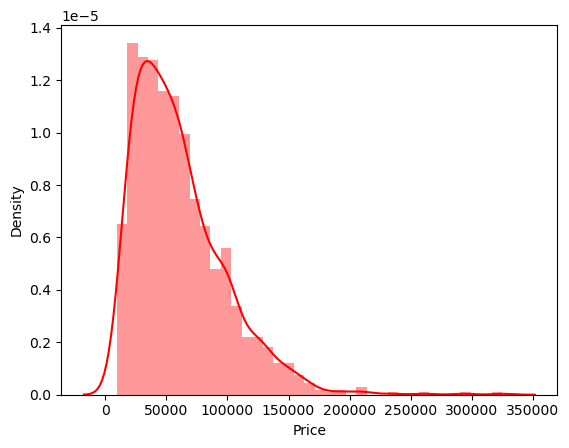

In [57]:
# Here we check the distribution of the price of laptop
# Distribution plot used for -> understand how your data is spread or distributed
sns.distplot(df["Price"],color="red")

In [58]:
df["Price"].max()  # Checking the maximum price of laptop

324954.72

In [59]:
df["Price"].min()  # Checking the minimum price of laptop

9270.72

C:\Users\HP\AppData\Local\Temp\ipykernel_3068\3558064521.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df[col],palette="plasma")
C:\Users\HP\AppData\Local\Temp\ipykernel_3068\3558064521.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df[col],palette="plasma")
C:\Users\HP\AppData\Local\Temp\ipykernel_3068\3558064521.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df[col],palette="plasma")


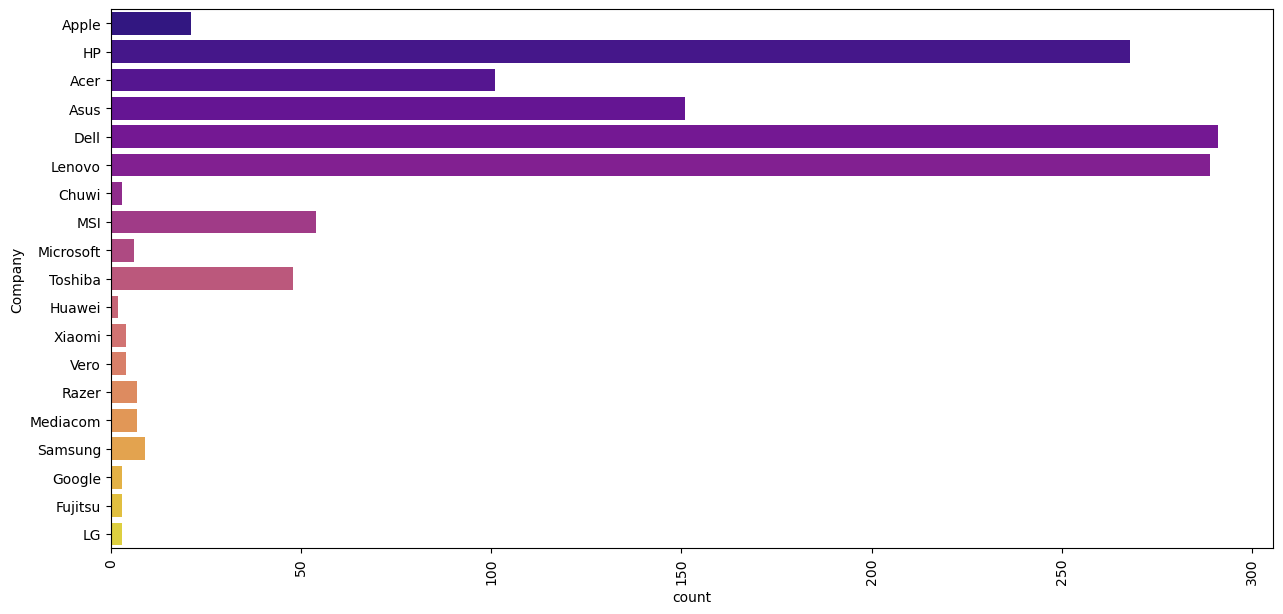

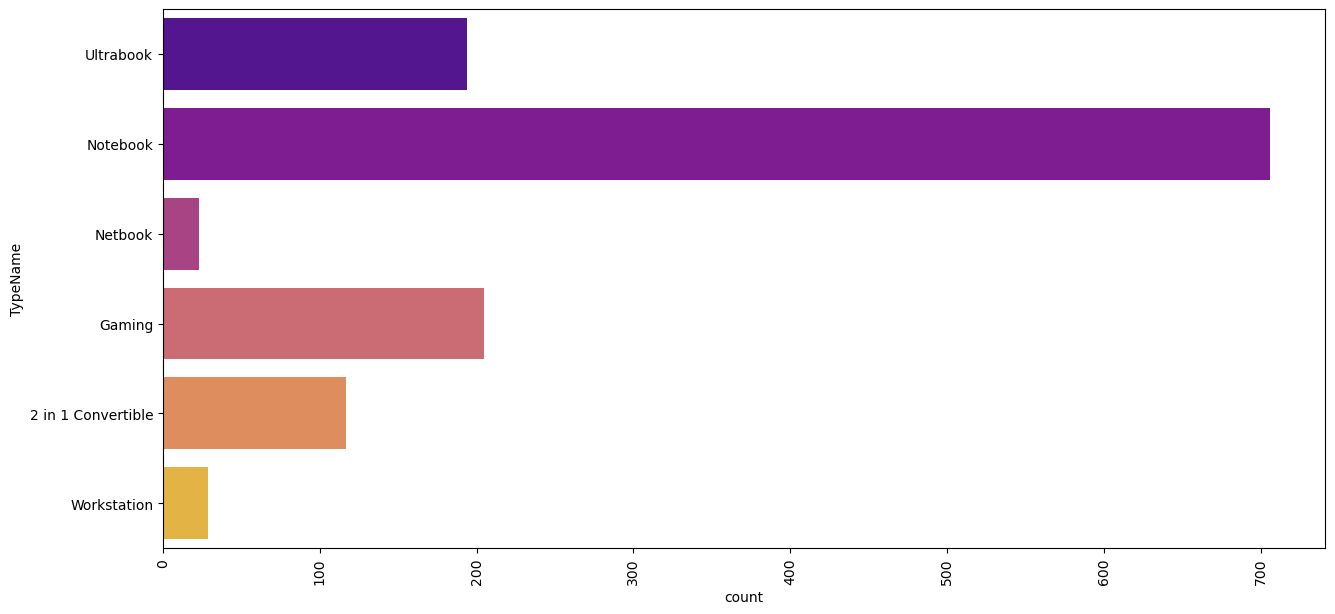

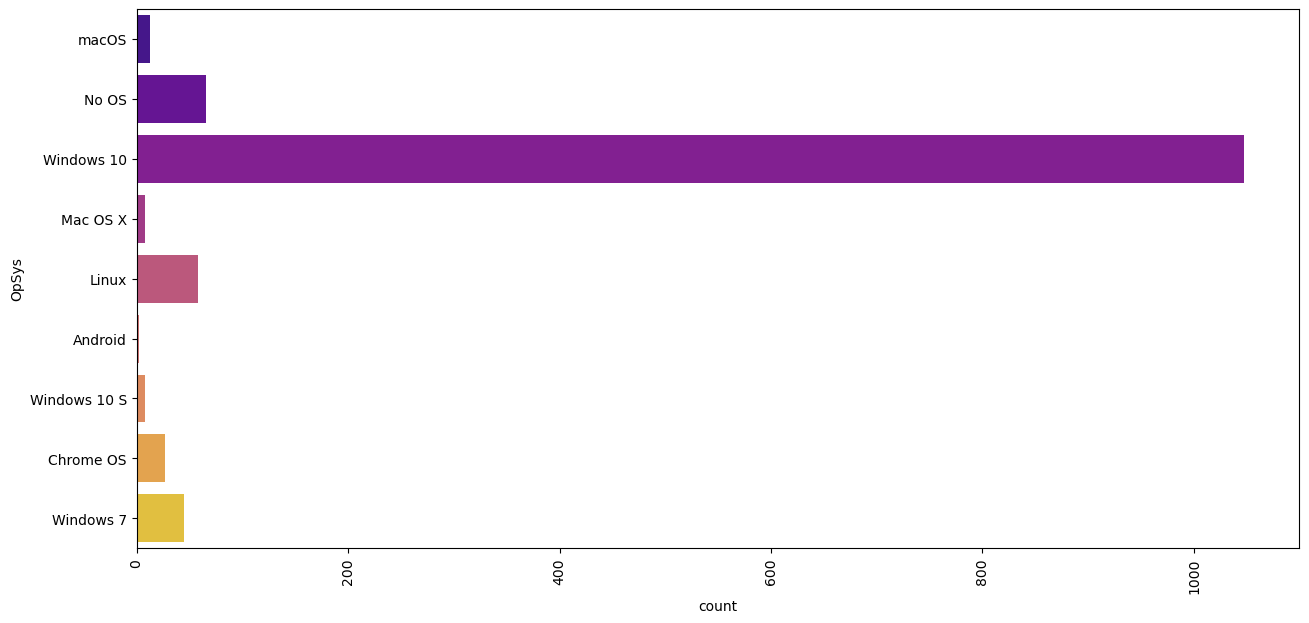

In [60]:
# Now ploting the chart for all categorical vairable

def drawplot(col):
    plt.figure(figsize=(15,7))  #entire canvas or page 
    sns.countplot(df[col],palette="plasma")
    plt.xticks(rotation="vertical")

toview = ["Company","TypeName","OpSys"]
for col in toview:
    drawplot(col)
    

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18],
 [Text(0, 0, 'Apple'),
  Text(1, 0, 'HP'),
  Text(2, 0, 'Acer'),
  Text(3, 0, 'Asus'),
  Text(4, 0, 'Dell'),
  Text(5, 0, 'Lenovo'),
  Text(6, 0, 'Chuwi'),
  Text(7, 0, 'MSI'),
  Text(8, 0, 'Microsoft'),
  Text(9, 0, 'Toshiba'),
  Text(10, 0, 'Huawei'),
  Text(11, 0, 'Xiaomi'),
  Text(12, 0, 'Vero'),
  Text(13, 0, 'Razer'),
  Text(14, 0, 'Mediacom'),
  Text(15, 0, 'Samsung'),
  Text(16, 0, 'Google'),
  Text(17, 0, 'Fujitsu'),
  Text(18, 0, 'LG')])

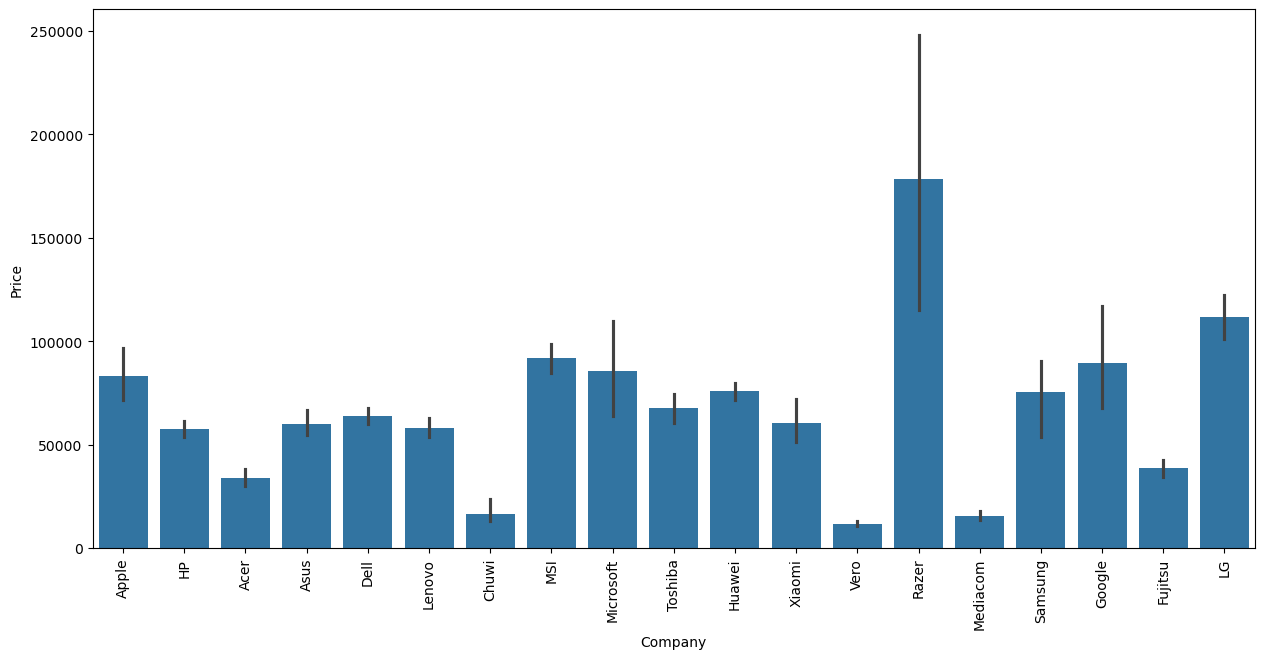

In [61]:
# What is the average prive of laptop of each brand

plt.figure(figsize=(15,7))
sns.barplot(x = df["Company"],y = df["Price"]) #A bar plot (bar chart) is used to compare values across different categories.
plt.xticks(rotation = "vertical")


([0, 1, 2, 3, 4, 5],
 [Text(0, 0, 'Ultrabook'),
  Text(1, 0, 'Notebook'),
  Text(2, 0, 'Netbook'),
  Text(3, 0, 'Gaming'),
  Text(4, 0, '2 in 1 Convertible'),
  Text(5, 0, 'Workstation')])

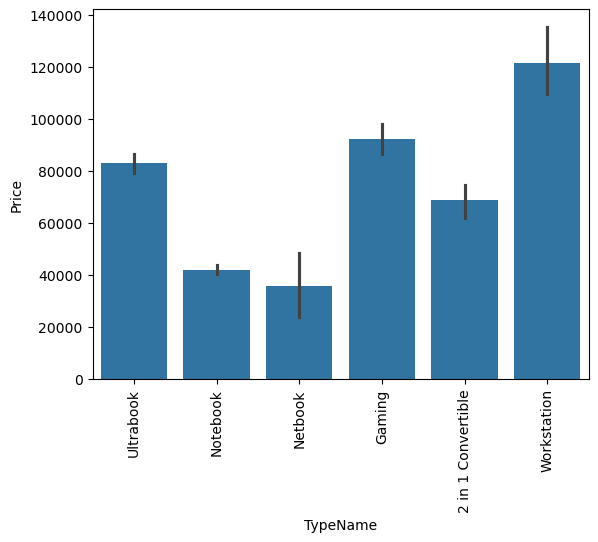

In [62]:
# What will be the avg price of each type of laptop
sns.barplot(x = df["TypeName"] , y = df["Price"])
plt.xticks(rotation="vertical")


(array([  0., 100., 200., 300., 400., 500., 600., 700., 800.]),
 [Text(0.0, 0, '0'),
  Text(100.0, 0, '100'),
  Text(200.0, 0, '200'),
  Text(300.0, 0, '300'),
  Text(400.0, 0, '400'),
  Text(500.0, 0, '500'),
  Text(600.0, 0, '600'),
  Text(700.0, 0, '700'),
  Text(800.0, 0, '800')])

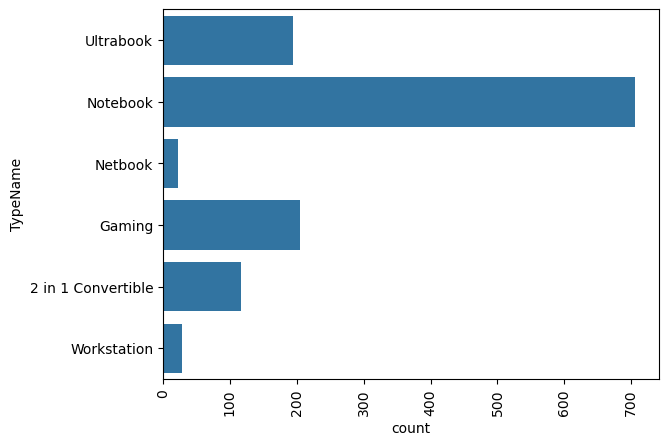

In [63]:
# the number of types of laptop
sns.countplot(df["TypeName"])
plt.xticks(rotation="vertical")

<Axes: xlabel='Inches', ylabel='Price'>

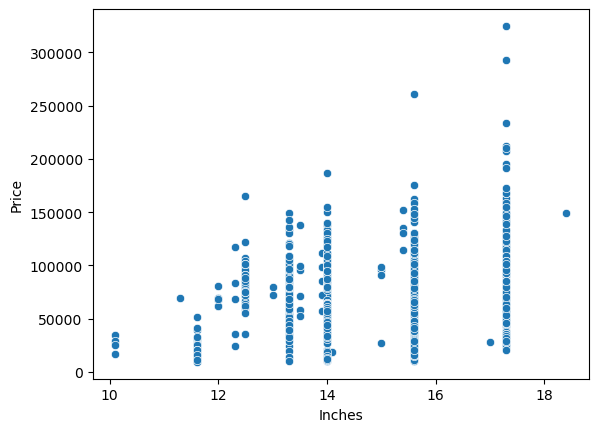

In [64]:
# variation of inches toword the price

sns.scatterplot(x = df["Inches"], y = df["Price"])

In [65]:
# Text PreProcessing- Screen Resolution

### Screen Resolution preprocessing

In [66]:
df["ScreenResolution"].value_counts()

ScreenResolution
Full HD 1920x1080                                505
1366x768                                         262
IPS Panel Full HD 1920x1080                      226
IPS Panel Full HD / Touchscreen 1920x1080         51
Full HD / Touchscreen 1920x1080                   47
1600x900                                          23
Touchscreen 1366x768                              16
Quad HD+ / Touchscreen 3200x1800                  15
IPS Panel 4K Ultra HD 3840x2160                   12
IPS Panel 4K Ultra HD / Touchscreen 3840x2160     11
4K Ultra HD / Touchscreen 3840x2160               10
4K Ultra HD 3840x2160                              7
Touchscreen 2560x1440                              7
IPS Panel 1366x768                                 7
IPS Panel Retina Display 2560x1600                 6
IPS Panel Retina Display 2304x1440                 6
Touchscreen 2256x1504                              6
IPS Panel Touchscreen 2560x1440                    5
IPS Panel Quad HD+ / Touchscr

In [67]:
df["TouchScreen"] = df["ScreenResolution"].apply(lambda element : 1 if "Touchscreen" in element else 0)
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0


In [68]:
df.tail()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen
1269,Asus,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,4,500GB HDD,Nvidia GeForce 920M,Windows 10,2.20,38378.6496,0
1270,Lenovo,2 in 1 Convertible,14.0,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.80,33992.6400,1
1271,Lenovo,2 in 1 Convertible,13.3,IPS Panel Quad HD+ / Touchscreen 3200x1800,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.30,79866.7200,1
1272,Lenovo,Notebook,14.0,1366x768,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.50,12201.1200,0
1273,HP,Notebook,15.6,1366x768,Intel Core i7 6500U 2.5GHz,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19,40705.9200,0


In [69]:
df.sample(10)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen
1043,Lenovo,Notebook,15.6,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8,256GB SSD,Intel HD Graphics 520,Windows 10,2.30,55922.688,0
969,Lenovo,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,6,256GB SSD,Nvidia GeForce 920MX,Windows 10,2.40,37029.600,0
1207,Lenovo,Notebook,15.6,1366x768,AMD E-Series 9000 2.2GHz,4,500GB HDD,AMD Radeon R2 Graphics,Windows 10,2.20,15930.720,0
168,Acer,Notebook,17.3,IPS Panel Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8,256GB SSD,Nvidia GeForce MX150,Windows 10,3.00,45501.120,0
1235,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,4,1TB HDD,Intel HD Graphics 520,Windows 10,2.10,25467.840,0
388,Dell,Workstation,15.6,IPS Panel Full HD 1920x1080,Intel Core i7 6820HQ 2.7GHz,8,256GB SSD,Nvidia Quadro M1200,Windows 10,2.00,113752.800,0
1229,MSI,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8,128GB SSD + 1TB HDD,Nvidia GeForce GTX 1050,Windows 10,2.20,61218.720,0
797,Dell,Notebook,15.6,1366x768,Intel Core i5 7200U 2.5GHz,8,128GB SSD,Intel HD Graphics 620,Windows 10,1.95,43156.800,0
519,Asus,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16,256GB SSD + 1TB HDD,Nvidia GeForce GTX1050 Ti,Windows 10,3.00,80133.120,0
648,Toshiba,Notebook,13.3,Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,8,256GB SSD,Intel HD Graphics 520,Windows 10,1.20,64628.640,0


In [70]:
df["TouchScreen"].value_counts()

TouchScreen
0    1086
1     188
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='TouchScreen'>

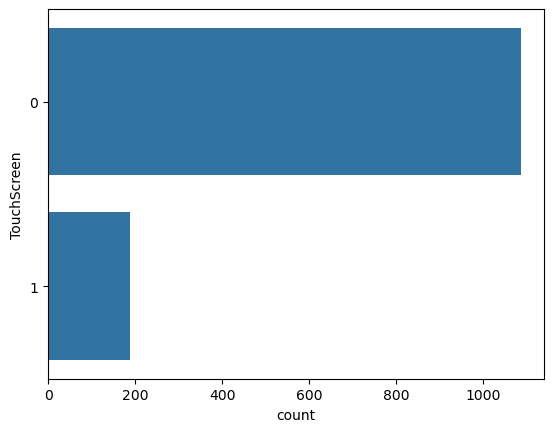

In [71]:
sns.countplot(df["TouchScreen"].astype(str))

([0, 1], [Text(0, 0, '0'), Text(1, 0, '1')])

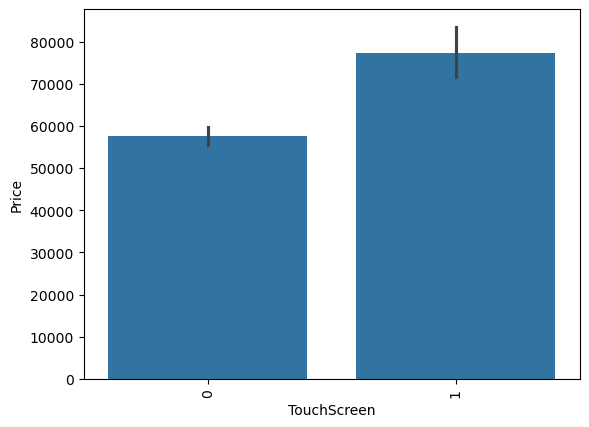

In [72]:
# Touch Screen on comparion with price of laptop
sns.barplot(x = df["TouchScreen"],y = df["Price"])
plt.xticks(rotation = "vertical")

In [73]:
df["IPS"]  = df["ScreenResolution"].apply(lambda element : 1 if "IPS" in element else 0)
df.sample(5)

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS
1086,HP,Workstation,15.6,Full HD 1920x1080,Intel Core i7 6500U 2.5GHz,8,256GB SSD,AMD FirePro W4190M,Windows 7,1.90,79653.60,0,0
690,Acer,Notebook,14.0,1366x768,Intel Celeron Dual Core 3855U 1.6GHz,4,32GB Flash Storage,Intel HD Graphics 510,Chrome OS,1.45,19980.00,0,0
837,Toshiba,Notebook,15.6,1366x768,Intel Core i3 7100U 2.4GHz,4,500GB HDD,Intel HD Graphics 620,Windows 10,2.00,35644.32,0,0
21,Lenovo,Gaming,15.6,IPS Panel Full HD 1920x1080,Intel Core i5 7300HQ 2.5GHz,8,128GB SSD + 1TB HDD,Nvidia GeForce GTX 1050,Windows 10,2.50,53226.72,0,1
963,Toshiba,Ultrabook,12.5,Full HD / Touchscreen 1920x1080,Intel Core i7 7500U 2.7GHz,8,512GB SSD,Intel HD Graphics 620,Windows 10,1.10,95371.20,1,0


<Axes: xlabel='count', ylabel='IPS'>

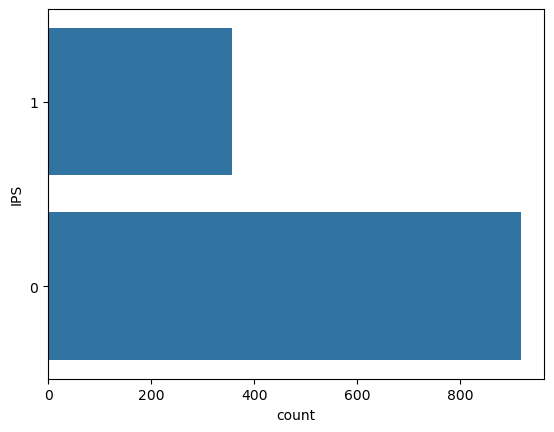

In [74]:
sns.countplot(df["IPS"].astype(str))

<Axes: xlabel='IPS', ylabel='Price'>

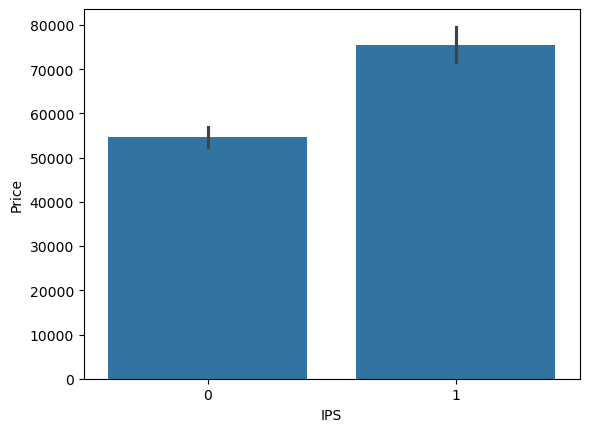

In [75]:
sns.barplot(x = df["IPS"], y = df["Price"])

In [76]:
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1


### Extarcting the X Resolution and the Y Resolution

In [77]:
splitdf = df["ScreenResolution"].str.split("x", n=1, expand=True)
splitdf

,0,1
0,IPS Panel Retina Display 2560,1600
1,1440,900
2,Full HD 1920,1080
3,IPS Panel Retina Display 2880,1800
4,IPS Panel Retina Display 2560,1600
...,...,...
1269,1366,768
1270,IPS Panel Full HD / Touchscreen 1920,1080
1271,IPS Panel Quad HD+ / Touchscreen 3200,1800
1272,1366,768


In [78]:
df["X-Res"] = splitdf[0]
df["Y-Res"] = splitdf[1]
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,X-Res,Y-Res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,IPS Panel Retina Display 2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,Full HD 1920,1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,IPS Panel Retina Display 2880,1800
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,IPS Panel Retina Display 2560,1600


In [79]:
'''from whole text column X-Res column we need to extract the digit.but here is the problem
that the number are scattered that why we use regx (regular expression). So firstly replace the "," and ""
in order to extract the number . from the string "\d+\.?\d+", \d means->interger number,\.?->all the number which come after the number
\d+-->string end with the numbers.'''

df['X-Res'] = df['X-Res'].astype(str).replace(',','').str.findall(r'(\d+\.?\d+)').apply(lambda x:x[0])

df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,X-Res,Y-Res
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600


In [80]:
df["X-Res"] = df["X-Res"].astype(int)
df["Y-Res"] = df["Y-Res"].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1274 entries, 0 to 1273
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           1274 non-null   object 
 1   TypeName          1274 non-null   object 
 2   Inches            1274 non-null   float64
 3   ScreenResolution  1274 non-null   object 
 4   Cpu               1274 non-null   object 
 5   Ram               1274 non-null   int32  
 6   Memory            1274 non-null   object 
 7   Gpu               1274 non-null   object 
 8   OpSys             1274 non-null   object 
 9   Weight            1274 non-null   float32
 10  Price             1274 non-null   float64
 11  TouchScreen       1274 non-null   int64  
 12  IPS               1274 non-null   int64  
 13  X-Res             1274 non-null   int64  
 14  Y-Res             1274 non-null   int64  
dtypes: float32(1), float64(2), int32(1), int64(4), object(7)
memory usage: 149.3+ KB


In [81]:
numeric_df = df.select_dtypes(include=["number"])
numeric_df.head()

,Inches,Ram,Weight,Price,TouchScreen,IPS,X-Res,Y-Res
0,13.3,8,1.37,71378.6832,0,1,2560,1600
1,13.3,8,1.34,47895.5232,0,0,1440,900
2,15.6,8,1.86,30636.0000,0,0,1920,1080
3,15.4,16,1.83,135195.3360,0,1,2880,1800
4,13.3,8,1.37,96095.8080,0,1,2560,1600


<Axes: >

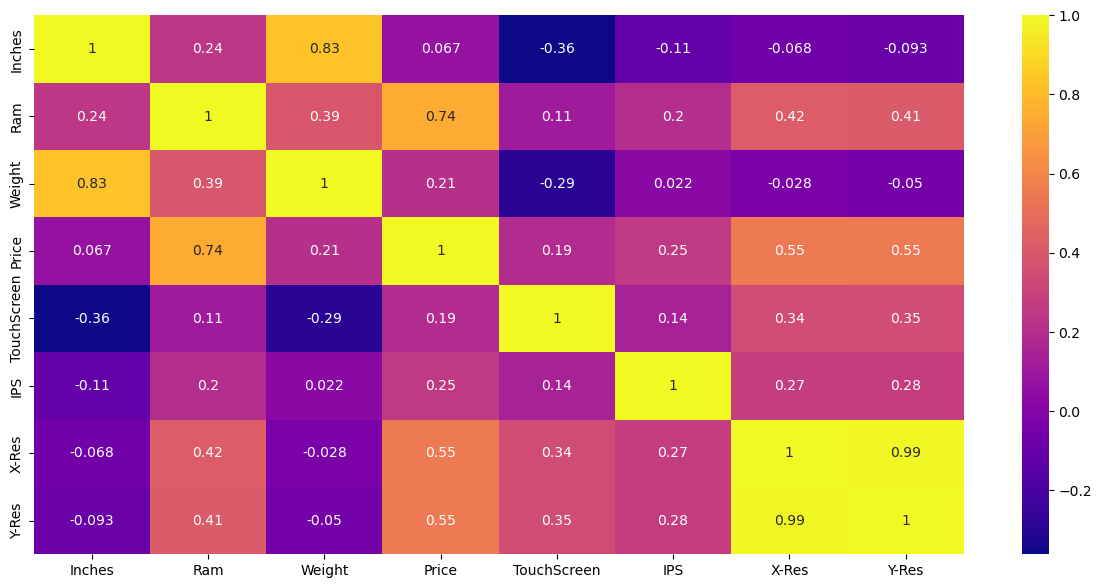

In [82]:
plt.figure(figsize=(15,7))
sns.heatmap(numeric_df.corr(),annot=True,cmap="plasma")

In [83]:
numeric_df.corr()["Price"]

Inches         0.066990
Ram            0.740106
Weight         0.212192
Price          1.000000
TouchScreen    0.188631
IPS            0.250358
X-Res          0.552074
Y-Res          0.548111
Name: Price, dtype: float64

### **From the correlation plot we observed that as the X_res and Y_res is increasing,the price of the laptop is also increasing,so `X_res and Y_res` are positively correlated and they are giving much information,so that is the reason why i had splitted `Resolution` column into `X_res and Y_res` columns respectively**

### **So to make things good,we can create a new column named `PPI{pixels per inch}`,now  as we saw from the correlation plot that the `X_res and Y_res` are having much collinearity,so why not combine them with `Inches` which is having less collinearity,so we will combine them as follows ↓,so here is the formula of how to calculate `PPI` {pixels per inch}**

###    

In [84]:
df["PPI"] = (((df["X-Res"]**2+df["Y-Res"]**2))**0.5/df["Inches"]).astype('float')
df.head()

,Company,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,X-Res,Y-Res,PPI
0,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,2560,1600,226.983005
1,Apple,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,1440,900,127.677940
2,HP,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,1920,1080,141.211998
3,Apple,Ultrabook,15.4,IPS Panel Retina Display 2880x1800,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,2880,1800,220.534624
4,Apple,Ultrabook,13.3,IPS Panel Retina Display 2560x1600,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,2560,1600,226.983005


In [85]:
numeric_df.corr()

,Inches,Ram,Weight,Price,TouchScreen,IPS,X-Res,Y-Res
Inches,1.000000,0.241441,0.826634,0.066990,-0.361873,-0.109942,-0.067916,-0.092768
Ram,0.241441,1.000000,0.389658,0.740106,0.111378,0.201446,0.423669,0.414816
Weight,0.826634,0.389658,1.000000,0.212192,-0.293933,0.022250,-0.028416,-0.049928
Price,0.066990,0.740106,0.212192,1.000000,0.188631,0.250358,0.552074,0.548111
TouchScreen,-0.361873,0.111378,-0.293933,0.188631,1.000000,0.139550,0.343077,0.350326
IPS,-0.109942,0.201446,0.022250,0.250358,0.139550,1.000000,0.271637,0.279652
X-Res,-0.067916,0.423669,-0.028416,0.552074,0.343077,0.271637,1.000000,0.994064
Y-Res,-0.092768,0.414816,-0.049928,0.548111,0.350326,0.279652,0.994064,1.000000


In [86]:
numeric_df = df.select_dtypes(include=["number"])
numeric_df.head()

,Inches,Ram,Weight,Price,TouchScreen,IPS,X-Res,Y-Res,PPI
0,13.3,8,1.37,71378.6832,0,1,2560,1600,226.983005
1,13.3,8,1.34,47895.5232,0,0,1440,900,127.677940
2,15.6,8,1.86,30636.0000,0,0,1920,1080,141.211998
3,15.4,16,1.83,135195.3360,0,1,2880,1800,220.534624
4,13.3,8,1.37,96095.8080,0,1,2560,1600,226.983005


In [87]:
numeric_df.corr()["Price"]

Inches         0.066990
Ram            0.740106
Weight         0.212192
Price          1.000000
TouchScreen    0.188631
IPS            0.250358
X-Res          0.552074
Y-Res          0.548111
PPI            0.469539
Name: Price, dtype: float64

In [88]:
# now we can delete extra column like x-res,y-res,inches,screenresolution
# So as we observe from the correlation data that the `PPI` is having good correlation,so we will be using that,
#as that is a combination of 3 features and that gives collective results of 3 columns,so we will drop `Inches,X_res,Y_res` as well.

In [89]:
df.drop(columns = ["Inches","Y-Res","X-Res","ScreenResolution"],inplace=True)
df.head()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPI
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005


##### Now we will work on CPU column,as that also has much text data and we need to process it efficiently as we may get good insights from them



In [90]:
df["CPU_Name"] = df["Cpu"].apply(lambda text : ' '.join(text.split()[:3]))
df.head()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_Name
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5


In [91]:
''' As mentioned earlier,if we get any of the intel `i3,i5 or i7` versions
we will return them as it is,but if we get any other processor
we will first check whether is that a variant of the intel? or not
if yes,then we will tag it as "Other Intel Processor" else we will
say it as `AMD Processor`
'''
def processortype(text):
    if text == "Intel Core i5" or text == "Intel Core i7" or text == "Intel Core i3":
        return text
    else:
        if text.split()[0] == "Intel":
            return "other intel processor"
        else:
            return "AMD"

df["CPU_Name"] = df["CPU_Name"].apply(lambda text:processortype(text))
df.head()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_Name
0,Apple,Ultrabook,Intel Core i5 2.3GHz,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5
1,Apple,Ultrabook,Intel Core i5 1.8GHz,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5
2,HP,Notebook,Intel Core i5 7200U 2.5GHz,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5
3,Apple,Ultrabook,Intel Core i7 2.7GHz,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7
4,Apple,Ultrabook,Intel Core i5 3.1GHz,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5


In [92]:
df.tail()

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_Name
1269,Asus,Notebook,Intel Core i7 6500U 2.5GHz,4,500GB HDD,Nvidia GeForce 920M,Windows 10,2.20,38378.6496,0,0,100.454670,Intel Core i7
1270,Lenovo,2 in 1 Convertible,Intel Core i7 6500U 2.5GHz,4,128GB SSD,Intel HD Graphics 520,Windows 10,1.80,33992.6400,1,1,157.350512,Intel Core i7
1271,Lenovo,2 in 1 Convertible,Intel Core i7 6500U 2.5GHz,16,512GB SSD,Intel HD Graphics 520,Windows 10,1.30,79866.7200,1,1,276.053530,Intel Core i7
1272,Lenovo,Notebook,Intel Celeron Dual Core N3050 1.6GHz,2,64GB Flash Storage,Intel HD Graphics,Windows 10,1.50,12201.1200,0,0,111.935204,other intel processor
1273,HP,Notebook,Intel Core i7 6500U 2.5GHz,6,1TB HDD,AMD Radeon R5 M330,Windows 10,2.19,40705.9200,0,0,100.454670,Intel Core i7


In [93]:
df.sample(5)

,Company,TypeName,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_Name
199,HP,Notebook,Intel Core i7 8550U 1.8GHz,8,256GB SSD,Nvidia GeForce 930MX,Windows 10,2.50,55677.60,0,0,127.335675,Intel Core i7
165,MSI,Gaming,Intel Core i7 7700HQ 2.8GHz,16,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,2.40,95850.72,0,1,141.211998,Intel Core i7
825,Toshiba,Notebook,Intel Pentium Dual Core 4405U 2.1GHz,4,128GB SSD,Intel HD Graphics 510,Windows 10,1.75,26586.72,0,0,111.935204,other intel processor
1183,Acer,Notebook,Intel Celeron Dual Core N3350 2GHz,4,500GB HDD,Intel HD Graphics 500,Windows 10,2.10,17742.24,0,0,100.454670,other intel processor
751,HP,Notebook,Intel Core i5 6300U 2.4GHz,8,256GB SSD,Intel HD Graphics 520,Windows 10,1.84,101232.00,0,0,141.211998,Intel Core i5


C:\Users\HP\AppData\Local\Temp\ipykernel_3068\1124239330.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df["CPU_Name"],palette = "plasma")


(array([  0., 100., 200., 300., 400., 500., 600.]),
 [Text(0.0, 0, '0'),
  Text(100.0, 0, '100'),
  Text(200.0, 0, '200'),
  Text(300.0, 0, '300'),
  Text(400.0, 0, '400'),
  Text(500.0, 0, '500'),
  Text(600.0, 0, '600')])

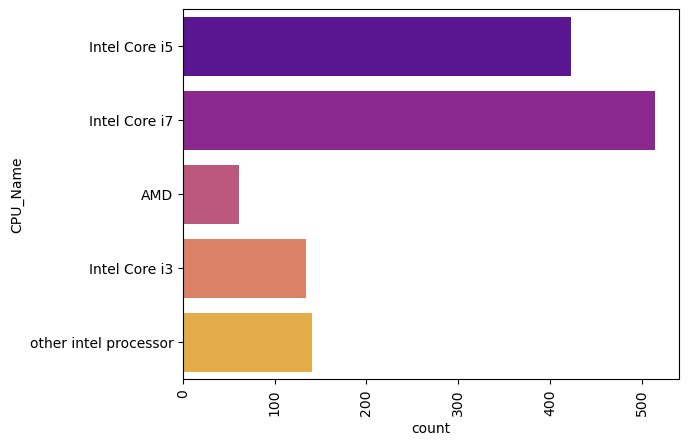

In [94]:
sns.countplot(df["CPU_Name"],palette = "plasma")
plt.xticks(rotation = "vertical")

([0, 1, 2, 3, 4],
 [Text(0, 0, 'Intel Core i5'),
  Text(1, 0, 'Intel Core i7'),
  Text(2, 0, 'AMD'),
  Text(3, 0, 'Intel Core i3'),
  Text(4, 0, 'other intel processor')])

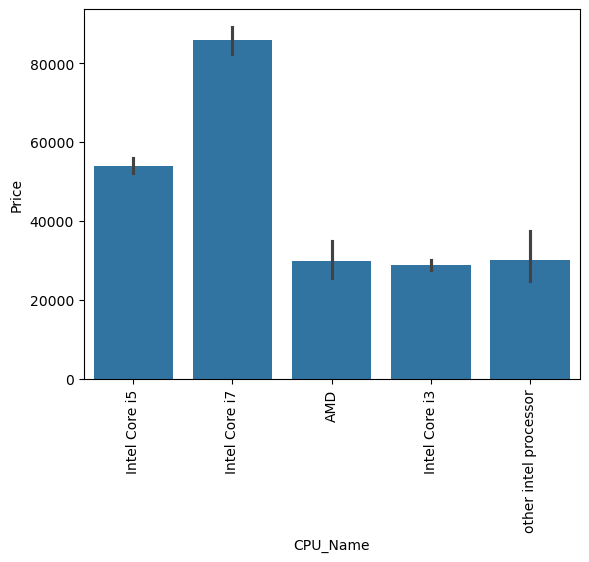

In [95]:
# price vs processor
sns.barplot(x = df["CPU_Name"],y = df["Price"])
plt.xticks(rotation = "vertical")

In [96]:
df.drop(columns = ["Cpu"],inplace = True)
df.head()

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_Name
0,Apple,Ultrabook,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5
1,Apple,Ultrabook,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5
2,HP,Notebook,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5
3,Apple,Ultrabook,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7
4,Apple,Ultrabook,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5


##### Analysis of RAM column

C:\Users\HP\AppData\Local\Temp\ipykernel_3068\4107968221.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df["Ram"].astype(str), palette = "autumn")


<Axes: xlabel='count', ylabel='Ram'>

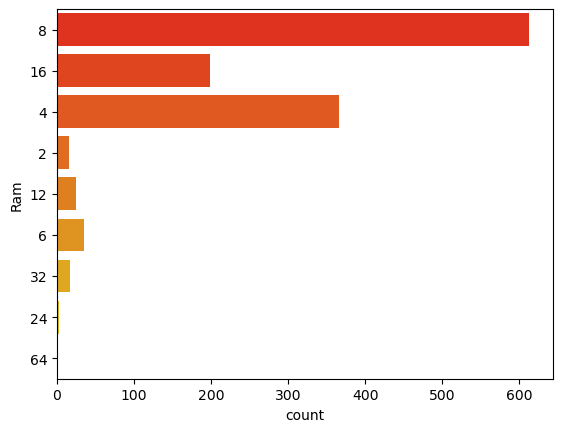

In [97]:
sns.countplot(df["Ram"].astype(str), palette = "autumn")

<Axes: xlabel='Ram', ylabel='Price'>

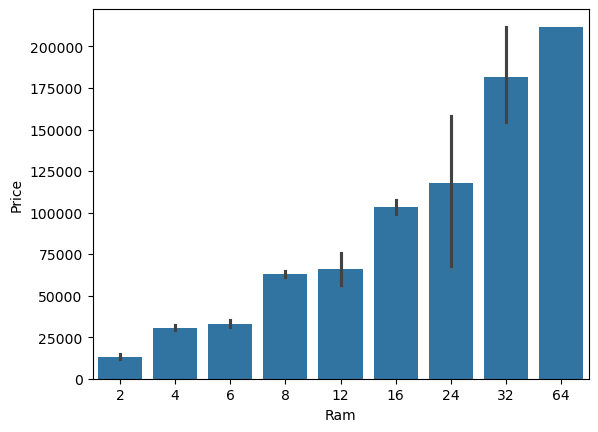

In [98]:
sns.barplot(x=df["Ram"],y=df["Price"])

####  Memory column analysis

In [99]:
df.head()

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_Name
0,Apple,Ultrabook,8,128GB SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5
1,Apple,Ultrabook,8,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5
2,HP,Notebook,8,256GB SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5
3,Apple,Ultrabook,16,512GB SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7
4,Apple,Ultrabook,8,256GB SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5


In [100]:
df["Memory"].value_counts()

Memory
256GB SSD                        412
1TB HDD                          215
500GB HDD                        123
512GB SSD                        114
128GB SSD +  1TB HDD              94
128GB SSD                         74
256GB SSD +  1TB HDD              73
32GB Flash Storage                36
2TB HDD                           16
512GB SSD +  1TB HDD              14
1TB SSD                           14
64GB Flash Storage                13
256GB SSD +  2TB HDD              10
256GB Flash Storage                8
16GB Flash Storage                 7
1.0TB Hybrid                       7
32GB SSD                           6
180GB SSD                          5
128GB Flash Storage                4
512GB SSD +  2TB HDD               3
16GB SSD                           3
512GB Flash Storage                2
1TB SSD +  1TB HDD                 2
256GB SSD +  500GB HDD             2
128GB SSD +  2TB HDD               2
256GB SSD +  256GB SSD             2
512GB SSD +  256GB SSD         

In [101]:
# 4 coomon vairiant are observed. HDD,SDD,Flash,Hybrid(HDD+SDD)
# remove decimal places 1.0-->1

df["Memory"] = df["Memory"].astype(str).replace('\.0','',regex=True)

# replace GB with ""

df["Memory"] = df["Memory"].str.replace("GB","")

# replace TB with 000

df["Memory"] = df["Memory"].str.replace("TB","000")

newdf = df["Memory"].str.split("+",n=1,expand=True)
newdf

,0,1
0,128 SSD,None
1,128 Flash Storage,None
2,256 SSD,None
3,512 SSD,None
4,256 SSD,None
...,...,...
1269,500 HDD,None
1270,128 SSD,None
1271,512 SSD,None
1272,64 Flash Storage,None


In [102]:
# remove the white spaces
df["first"] = newdf[0]
df["first"] = df["first"].str.strip()
df.head()

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_Name,first
0,Apple,Ultrabook,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,128 SSD
1,Apple,Ultrabook,8,128 Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,128 Flash Storage
2,HP,Notebook,8,256 SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,256 SSD
3,Apple,Ultrabook,16,512 SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,512 SSD
4,Apple,Ultrabook,8,256 SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,256 SSD


In [103]:
def applychanges(value):
    
    df["Layer1"+value] = df["first"].apply(lambda x : 1 if value in x else 0)


listtoapply = ["HDD","SSD","Hybrid","Flash Storage"]
for value in listtoapply:
    applychanges(value)
df.head()

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_Name,first,Layer1HDD,Layer1SSD,Layer1Hybrid,Layer1Flash Storage
0,Apple,Ultrabook,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,128 SSD,0,1,0,0
1,Apple,Ultrabook,8,128 Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,128 Flash Storage,0,0,0,1
2,HP,Notebook,8,256 SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,256 SSD,0,1,0,0
3,Apple,Ultrabook,16,512 SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,512 SSD,0,1,0,0
4,Apple,Ultrabook,8,256 SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,256 SSD,0,1,0,0


In [104]:
df.sample(5)

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_Name,first,Layer1HDD,Layer1SSD,Layer1Hybrid,Layer1Flash Storage
546,Lenovo,Notebook,4,500 HDD,Intel HD Graphics 620,Windows 10,1.87,41824.8,0,0,157.350512,Intel Core i5,500 HDD,1,0,0,0
667,HP,Notebook,8,1000 HDD,AMD Radeon 530,Windows 10,2.10,39693.6,0,0,141.211998,Intel Core i7,1000 HDD,1,0,0,0
926,Lenovo,Ultrabook,8,256 SSD,Intel HD Graphics 620,Windows 10,1.36,87912.0,0,1,176.232574,Intel Core i7,256 SSD,0,1,0,0
742,Toshiba,Notebook,8,256 SSD,Intel HD Graphics 620,Windows 10,1.25,81784.8,1,1,157.350512,Intel Core i5,256 SSD,0,1,0,0
1179,HP,Notebook,4,500 HDD,Intel HD Graphics 520,Windows 10,2.07,34632.0,0,0,100.454670,Intel Core i3,500 HDD,1,0,0,0


In [105]:
# remove all the character just keep the number

df['first'] = df['first'].str.replace(r'\D', '', regex=True)
df['first'].value_counts()

first
256     508
1000    240
128     175
512     136
500     123
32       43
2000     16
64       15
16       10
180       5
240       1
8         1
508       1
Name: count, dtype: int64

In [106]:
df["Second"] = newdf[1]
df["Second"] = df["Second"].str.strip()
df.head()

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_Name,first,Layer1HDD,Layer1SSD,Layer1Hybrid,Layer1Flash Storage,Second
0,Apple,Ultrabook,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,128,0,1,0,0,None
1,Apple,Ultrabook,8,128 Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,128,0,0,0,1,None
2,HP,Notebook,8,256 SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,256,0,1,0,0,None
3,Apple,Ultrabook,16,512 SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,512,0,1,0,0,None
4,Apple,Ultrabook,8,256 SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,256,0,1,0,0,None


In [107]:
def applychanges1(value):
    
    df["Layer2"+value] = df["Second"].apply(lambda x : 1 if value in x else 0)


listtoapply1 = ["HDD","SSD","Hybrid","Flash Storage"]
df["Second"] = df["Second"].fillna("0")
for value in listtoapply1:
    applychanges1(value)


df.head()

df['Second'] = df['Second'].str.replace(r'\D', '', regex=True)
df['Second'].value_counts()

Second
0       1066
1000     187
2000      15
256        3
500        2
512        1
Name: count, dtype: int64

In [108]:
df.head()

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,...,first,Layer1HDD,Layer1SSD,Layer1Hybrid,Layer1Flash Storage,Second,Layer2HDD,Layer2SSD,Layer2Hybrid,Layer2Flash Storage
0,Apple,Ultrabook,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,...,128,0,1,0,0,0,0,0,0,0
1,Apple,Ultrabook,8,128 Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,...,128,0,0,0,1,0,0,0,0,0
2,HP,Notebook,8,256 SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,...,256,0,1,0,0,0,0,0,0,0
3,Apple,Ultrabook,16,512 SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,...,512,0,1,0,0,0,0,0,0,0
4,Apple,Ultrabook,8,256 SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,...,256,0,1,0,0,0,0,0,0,0


In [109]:
df["first"] = df["first"].astype(int)
df["Second"] = df["Second"].astype(int)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1274 entries, 0 to 1273
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Company              1274 non-null   object 
 1   TypeName             1274 non-null   object 
 2   Ram                  1274 non-null   int32  
 3   Memory               1274 non-null   object 
 4   Gpu                  1274 non-null   object 
 5   OpSys                1274 non-null   object 
 6   Weight               1274 non-null   float32
 7   Price                1274 non-null   float64
 8   TouchScreen          1274 non-null   int64  
 9   IPS                  1274 non-null   int64  
 10  PPI                  1274 non-null   float64
 11  CPU_Name             1274 non-null   object 
 12  first                1274 non-null   int64  
 13  Layer1HDD            1274 non-null   int64  
 14  Layer1SSD            1274 non-null   int64  
 15  Layer1Hybrid         1274 non-null   int64 

In [110]:
# multiplying the elements and storing the result in subsequent columns


df["HDD"]=(df["first"]*df["Layer1HDD"]+df["Second"]*df["Layer2HDD"])
df["SSD"]=(df["first"]*df["Layer1SSD"]+df["Second"]*df["Layer2SSD"])
df["Hybrid"]=(df["first"]*df["Layer1Hybrid"]+df["Second"]*df["Layer2Hybrid"])
df["Flash_Storage"]=(df["first"]*df["Layer1Flash Storage"]+df["Second"]*df["Layer2Flash Storage"])


## dropping of uncessary columns

df.drop(columns=['first', 'Second', 'Layer1HDD', 'Layer1SSD', 'Layer1Hybrid',
       'Layer1Flash Storage', 'Layer2HDD', 'Layer2SSD', 'Layer2Hybrid',
       'Layer2Flash Storage'],inplace=True)

In [111]:
df.head()

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_Name,HDD,SSD,Hybrid,Flash_Storage
0,Apple,Ultrabook,8,128 SSD,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,0,0
1,Apple,Ultrabook,8,128 Flash Storage,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,0,128
2,HP,Notebook,8,256 SSD,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,0,0
3,Apple,Ultrabook,16,512 SSD,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,0,0
4,Apple,Ultrabook,8,256 SSD,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,0,0


In [112]:
df.sample(5)

,Company,TypeName,Ram,Memory,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_Name,HDD,SSD,Hybrid,Flash_Storage
46,Lenovo,Notebook,4,128 SSD,Intel HD Graphics 520,No OS,2.20,19660.3200,0,0,100.454670,Intel Core i3,0,128,0,0
199,HP,Notebook,8,256 SSD,Nvidia GeForce 930MX,Windows 10,2.50,55677.6000,0,0,127.335675,Intel Core i7,0,256,0,0
1162,HP,Gaming,8,1000 HDD,Nvidia GeForce GTX 1050,Windows 10,2.62,47898.7200,0,1,141.211998,Intel Core i7,1000,0,0,0
117,Dell,Notebook,8,256 SSD + 1000 HDD,Nvidia GeForce 940MX,Windows 10,2.16,60223.9824,0,1,141.211998,Intel Core i7,1000,256,0,0
295,Lenovo,Gaming,8,1000 HDD,Nvidia GeForce GTX 1060,Windows 10,3.20,69210.7200,0,1,141.211998,Intel Core i7,1000,0,0,0


In [113]:
df.drop(columns=['Memory'],inplace=True)

In [114]:
df.head()

,Company,TypeName,Ram,Gpu,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_Name,HDD,SSD,Hybrid,Flash_Storage
0,Apple,Ultrabook,8,Intel Iris Plus Graphics 640,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,0,0
1,Apple,Ultrabook,8,Intel HD Graphics 6000,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,0,128
2,HP,Notebook,8,Intel HD Graphics 620,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,0,0
3,Apple,Ultrabook,16,AMD Radeon Pro 455,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,0,0
4,Apple,Ultrabook,8,Intel Iris Plus Graphics 650,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,0,0


In [115]:
numeric_df = df.select_dtypes(include=["number"])
numeric_df.head()

,Ram,Weight,Price,TouchScreen,IPS,PPI,HDD,SSD,Hybrid,Flash_Storage
0,8,1.37,71378.6832,0,1,226.983005,0,128,0,0
1,8,1.34,47895.5232,0,0,127.677940,0,0,0,128
2,8,1.86,30636.0000,0,0,141.211998,0,256,0,0
3,16,1.83,135195.3360,0,1,220.534624,0,512,0,0
4,8,1.37,96095.8080,0,1,226.983005,0,256,0,0


In [116]:
numeric_df.corr()['Price']

Ram              0.740106
Weight           0.212192
Price            1.000000
TouchScreen      0.188631
IPS              0.250358
PPI              0.469539
HDD             -0.098011
SSD              0.669957
Hybrid           0.022533
Flash_Storage   -0.037176
Name: Price, dtype: float64

### **Based on the correlation we observe that `Hybrid` and `Flash Storage` are almost negligible,so we can simply drop them off,where as HDD and SDD are having good correlation,we find that HDD has -ve relation with Price,and that's true,if the price of laptop is increasing there is more probability that the laptop is gonna use SDD instead of HDD and vice versa as well**

In [117]:
df.columns

Index(['Company', 'TypeName', 'Ram', 'Gpu', 'OpSys', 'Weight', 'Price',
       'TouchScreen', 'IPS', 'PPI', 'CPU_Name', 'HDD', 'SSD', 'Hybrid',
       'Flash_Storage'],
      dtype='object')

In [118]:
df.drop(columns = ['Flash_Storage','Hybrid'],inplace =True)

###  Analysis on GPU

In [119]:
df['Gpu'].value_counts()

Gpu
Intel HD Graphics 620      279
Intel HD Graphics 520      181
Intel UHD Graphics 620      68
Nvidia GeForce GTX 1050     66
Nvidia GeForce GTX 1060     48
                          ... 
AMD Radeon R5 520            1
AMD Radeon R7                1
Intel HD Graphics 540        1
AMD Radeon 540               1
ARM Mali T860 MP4            1
Name: count, Length: 110, dtype: int64

In [120]:
# a=df['Gpu'].iloc[1]
# print(a.split()[0])

In [121]:
df['Gpu_brand'] = df['Gpu'].apply(lambda x:x.split()[0])

C:\Users\HP\AppData\Local\Temp\ipykernel_3068\2531566187.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df['Gpu_brand'],palette="plasma")


<Axes: xlabel='count', ylabel='Gpu_brand'>

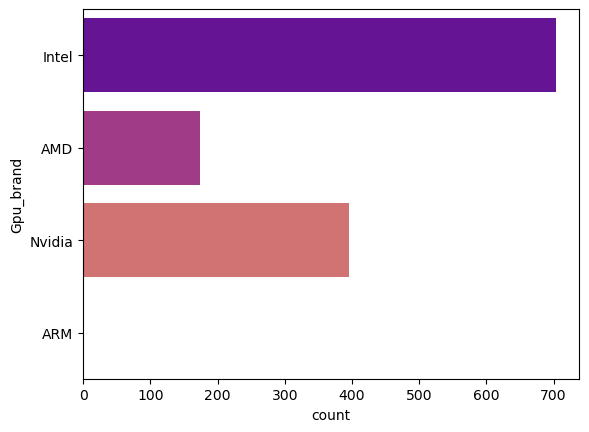

In [122]:
sns.countplot(df['Gpu_brand'],palette="plasma")

C:\Users\HP\AppData\Local\Temp\ipykernel_3068\1303730843.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df['Gpu_brand'],palette = 'plasma')


<Axes: xlabel='count', ylabel='Gpu_brand'>

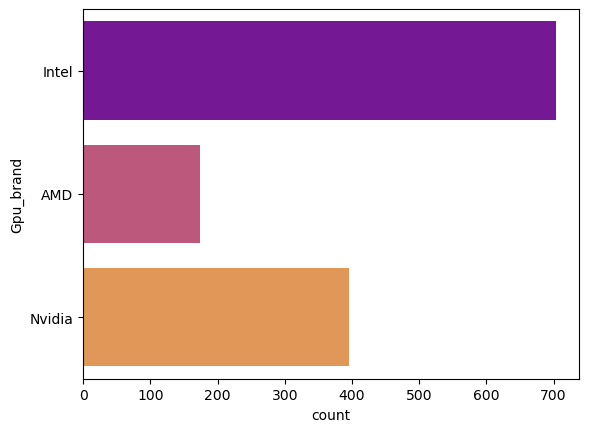

In [123]:
df = df[df['Gpu_brand']!='ARM']
sns.countplot(df['Gpu_brand'],palette = 'plasma')

<Axes: xlabel='Gpu_brand', ylabel='Price'>

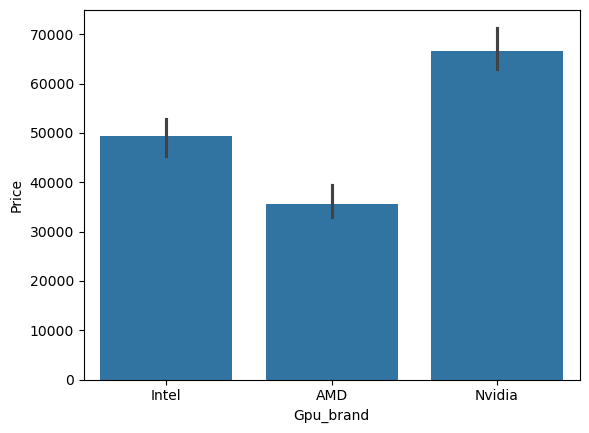

In [124]:
sns.barplot(x=df['Gpu_brand'],y=df['Price'],estimator=np.median)

In [125]:
df.drop(columns=['Gpu'],inplace=True)

In [126]:
df.head()

,Company,TypeName,Ram,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_Name,HDD,SSD,Gpu_brand
0,Apple,Ultrabook,8,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel
1,Apple,Ultrabook,8,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,Intel
2,HP,Notebook,8,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,Intel
3,Apple,Ultrabook,16,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,AMD
4,Apple,Ultrabook,8,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,Intel


### Analysis on OS

In [127]:
df['OpSys'].value_counts()

OpSys
Windows 10      1047
No OS             66
Linux             58
Windows 7         45
Chrome OS         26
macOS             13
Mac OS X           8
Windows 10 S       8
Android            2
Name: count, dtype: int64

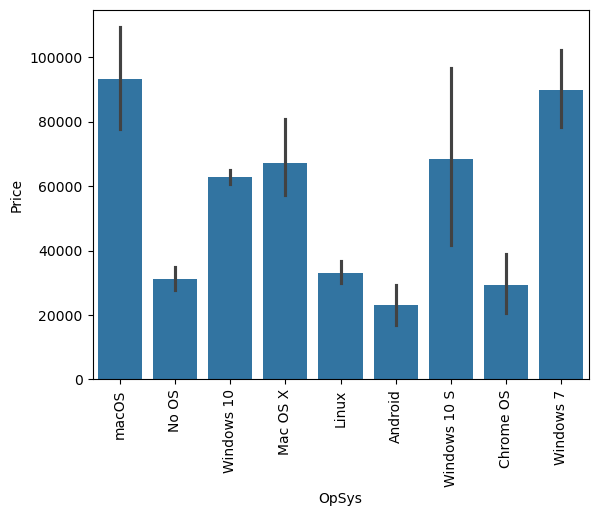

In [128]:
sns.barplot(x=df['OpSys'],y=df['Price'])
plt.xticks(rotation = 'vertical')
plt.show()

In [129]:
df['OpSys'].unique()

array(['macOS', 'No OS', 'Windows 10', 'Mac OS X', 'Linux', 'Android',
       'Windows 10 S', 'Chrome OS', 'Windows 7'], dtype=object)

In [130]:
df.head()

,Company,TypeName,Ram,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_Name,HDD,SSD,Gpu_brand
0,Apple,Ultrabook,8,macOS,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel
1,Apple,Ultrabook,8,macOS,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,Intel
2,HP,Notebook,8,No OS,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,Intel
3,Apple,Ultrabook,16,macOS,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,AMD
4,Apple,Ultrabook,8,macOS,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,Intel


In [131]:
def setcategory(text):
    
    if text=='Windows 10' or text=='Windows 7' or text=='Windows 10 S':
        return 'Windows'
    
    elif text=='Mac OS X' or text=='macOS':
        return 'Mac'
    
    else:
        return 'Other'
    
    
df['OpSys'] = df['OpSys'].apply(lambda x:setcategory(x))

df.head()

,Company,TypeName,Ram,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_Name,HDD,SSD,Gpu_brand
0,Apple,Ultrabook,8,Mac,1.37,71378.6832,0,1,226.983005,Intel Core i5,0,128,Intel
1,Apple,Ultrabook,8,Mac,1.34,47895.5232,0,0,127.677940,Intel Core i5,0,0,Intel
2,HP,Notebook,8,Other,1.86,30636.0000,0,0,141.211998,Intel Core i5,0,256,Intel
3,Apple,Ultrabook,16,Mac,1.83,135195.3360,0,1,220.534624,Intel Core i7,0,512,AMD
4,Apple,Ultrabook,8,Mac,1.37,96095.8080,0,1,226.983005,Intel Core i5,0,256,Intel


In [132]:
df.sample(7)

,Company,TypeName,Ram,OpSys,Weight,Price,TouchScreen,IPS,PPI,CPU_Name,HDD,SSD,Gpu_brand
692,HP,Workstation,8,Windows,3.14,101657.7072,0,0,127.335675,Intel Core i7,500,0,Nvidia
794,Apple,Ultrabook,8,Mac,0.92,62071.2000,0,1,226.415547,other intel processor,0,0,Intel
750,Lenovo,Netbook,4,Windows,1.40,25308.0000,1,0,135.094211,other intel processor,0,128,Intel
477,Lenovo,Notebook,8,Windows,1.70,72673.9200,0,0,157.350512,Intel Core i5,0,180,Intel
1146,HP,Ultrabook,8,Windows,1.26,122381.4960,0,0,176.232574,Intel Core i7,0,256,Intel
406,Toshiba,Ultrabook,16,Windows,1.20,93080.1600,0,0,165.632118,Intel Core i7,0,512,Intel
688,HP,Notebook,6,Windows,2.65,30316.3200,0,1,127.335675,AMD,2000,0,AMD


C:\Users\HP\AppData\Local\Temp\ipykernel_3068\430762393.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df['OpSys'],palette='plasma')


<Axes: xlabel='count', ylabel='OpSys'>

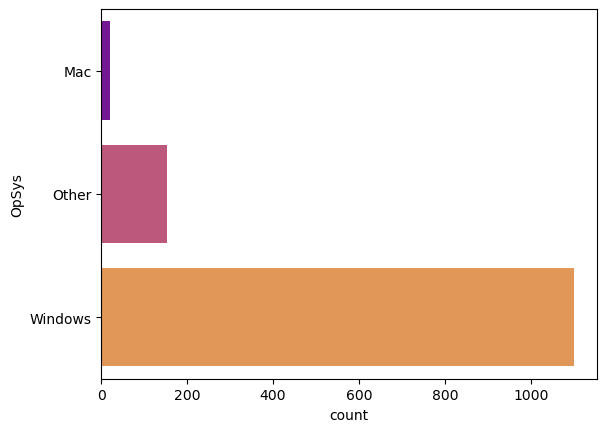

In [133]:
sns.countplot(df['OpSys'],palette='plasma')


([0, 1, 2], [Text(0, 0, 'Mac'), Text(1, 0, 'Other'), Text(2, 0, 'Windows')])

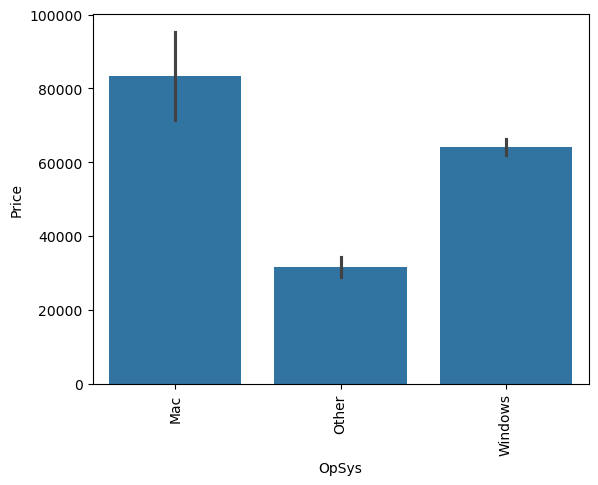

In [134]:
sns.barplot(x=df['OpSys'],y=df['Price'])
plt.xticks(rotation='vertical')

### Weight Analysis


C:\Users\HP\AppData\Local\Temp\ipykernel_3068\1125578356.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Weight'])


<Axes: xlabel='Weight', ylabel='Density'>

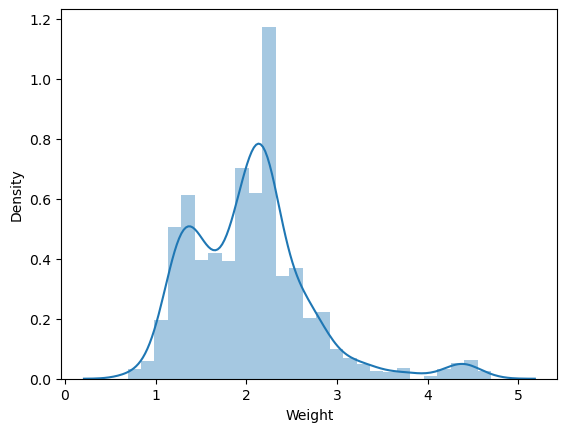

In [135]:
sns.distplot(df['Weight'])

<Axes: xlabel='Weight', ylabel='Count'>

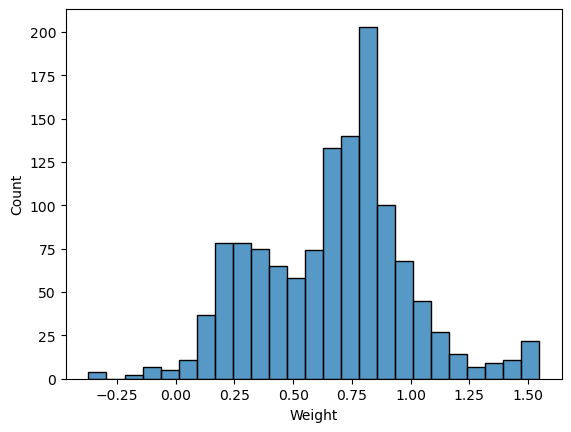

In [202]:
sns.histplot(np.log(df['Weight']))

<Axes: xlabel='Weight', ylabel='Price'>

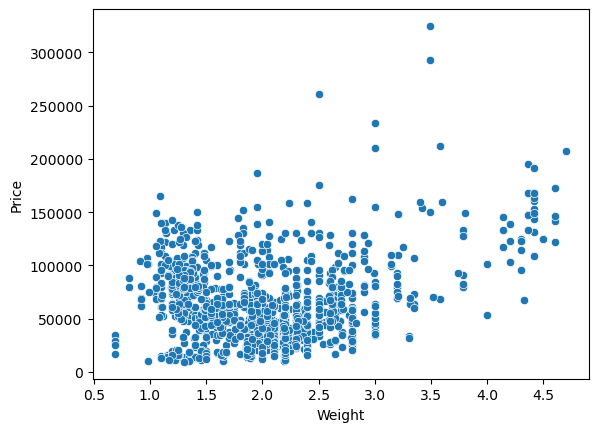

In [136]:
sns.scatterplot(x=df['Weight'],y=df['Price'])

### Price Analysis

C:\Users\HP\AppData\Local\Temp\ipykernel_5364\834922981.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Price'])


<Axes: xlabel='Price', ylabel='Density'>

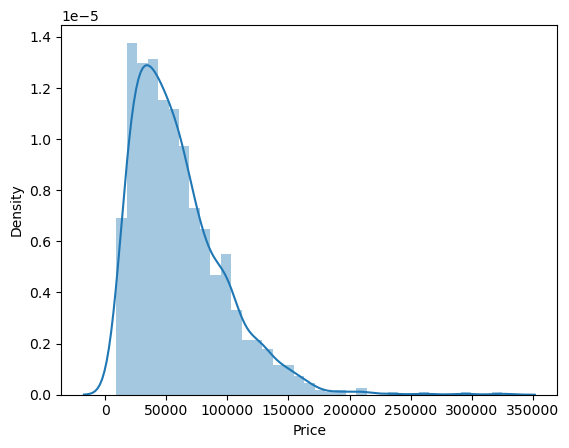

In [139]:
sns.distplot(df['Price'])

<Axes: xlabel='Price', ylabel='Count'>

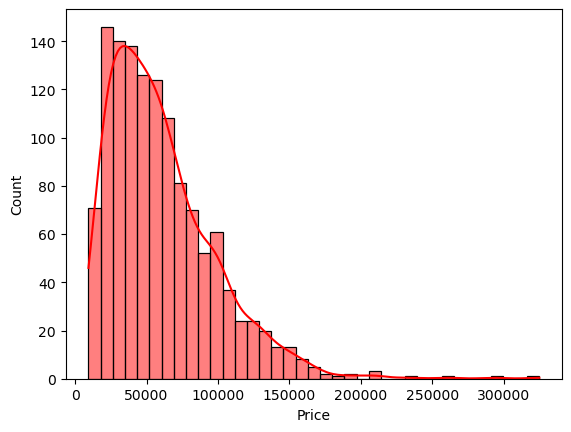

In [137]:
sns.histplot(df["Price"], kde=True, color="red")

C:\Users\HP\AppData\Local\Temp\ipykernel_3068\4185180355.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log(df['Price']))   #skewed distribution ---->>>This tells to apply log transformation


<Axes: xlabel='Price', ylabel='Density'>

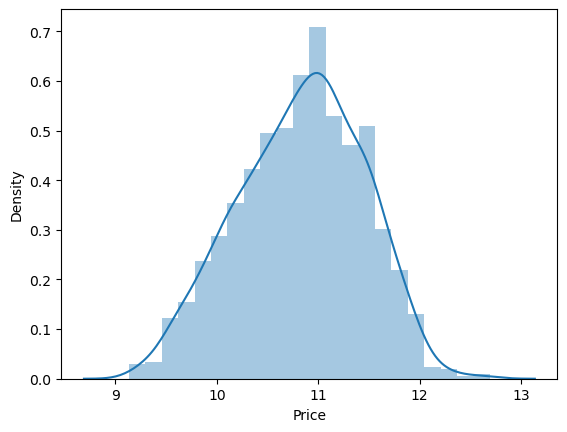

In [138]:
sns.distplot(np.log(df['Price']))   #skewed distribution ---->>>This tells to apply log transformation

<Axes: xlabel='Price', ylabel='Count'>

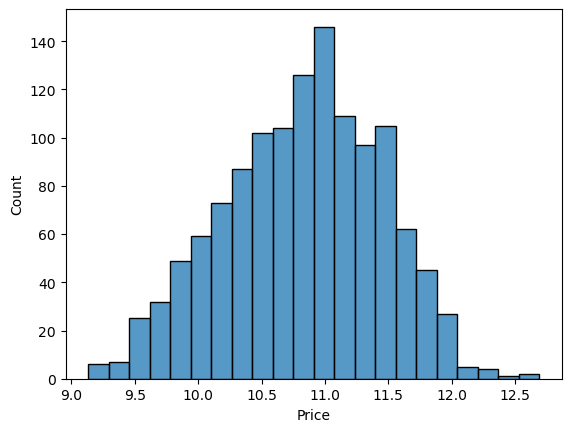

In [201]:
sns.histplot(np.log(df['Price']))

<Axes: >

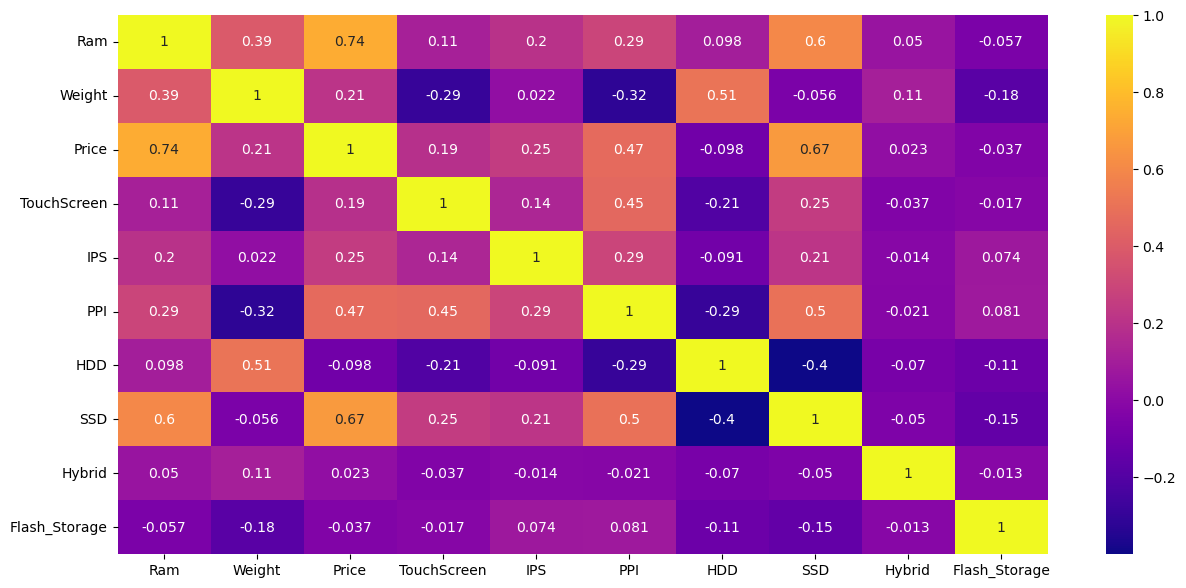

In [139]:
plt.figure(figsize=(15,7))
sns.heatmap(numeric_df.corr(),annot=True,cmap='plasma')

In [140]:
list(df['Price'])[0:5]

[71378.6832, 47895.5232, 30636.0, 135195.33599999998, 96095.808]

In [141]:
np.log(71378.6832)

np.float64(11.175754549129524)

In [142]:
np.exp(11.175754549129524)

np.float64(71378.68320000001)

### Model Building

In [143]:
test = np.log(df['Price'])
train = df.drop(['Price'],axis=1)

In [144]:
train

,Company,TypeName,Ram,OpSys,Weight,TouchScreen,IPS,PPI,CPU_Name,HDD,SSD,Gpu_brand
0,Apple,Ultrabook,8,Mac,1.37,0,1,226.983005,Intel Core i5,0,128,Intel
1,Apple,Ultrabook,8,Mac,1.34,0,0,127.677940,Intel Core i5,0,0,Intel
2,HP,Notebook,8,Other,1.86,0,0,141.211998,Intel Core i5,0,256,Intel
3,Apple,Ultrabook,16,Mac,1.83,0,1,220.534624,Intel Core i7,0,512,AMD
4,Apple,Ultrabook,8,Mac,1.37,0,1,226.983005,Intel Core i5,0,256,Intel
...,...,...,...,...,...,...,...,...,...,...,...,...
1269,Asus,Notebook,4,Windows,2.20,0,0,100.454670,Intel Core i7,500,0,Nvidia
1270,Lenovo,2 in 1 Convertible,4,Windows,1.80,1,1,157.350512,Intel Core i7,0,128,Intel
1271,Lenovo,2 in 1 Convertible,16,Windows,1.30,1,1,276.053530,Intel Core i7,0,512,Intel
1272,Lenovo,Notebook,2,Windows,1.50,0,0,111.935204,other intel processor,0,0,Intel


In [145]:
test

0       11.175755
1       10.776777
2       10.329931
3       11.814476
4       11.473101
          ...    
1269    10.555257
1270    10.433899
1271    11.288115
1272     9.409283
1273    10.614129
Name: Price, Length: 1273, dtype: float64

In [146]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler,StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn import metrics
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn import tree

In [147]:
! pip install xgboost

In [148]:
x_train,x_test,y_train,y_test = train_test_split(train,test,test_size=0.15, random_state=2)
x_train.shape, x_test.shape

((1082, 12), (191, 12))

### thers is a class which we imported name as column transformer, widely used when buldling our model using pipeline, so for this we have to get index number of column which have calegorical vairables

In [171]:
mapper = {i : value for i , value in enumerate(x_train.columns)}  #column transformer used for categorical columns
mapper

{0: 'Company',
 1: 'TypeName',
 2: 'Ram',
 3: 'OpSys',
 4: 'Weight',
 5: 'TouchScreen',
 6: 'IPS',
 7: 'PPI',
 8: 'CPU_Name',
 9: 'HDD',
 10: 'SSD',
 11: 'Gpu_brand'}

###  Linear regression

In [172]:
step1 = ColumnTransformer(transformers=[('col_tnf',OneHotEncoder(sparse_output=False, drop = 'first'),[0,1,3,8,11])],remainder='passthrough')

step2 = LinearRegression()

pipe = Pipeline([('step1',step1),('step2',step2)])

pipe.fit(x_train,y_train)

y_pred = pipe.predict(x_test)

print('r2_score', metrics.r2_score(y_test,y_pred))
print('MAE',metrics.mean_absolute_error(y_test,y_pred))

r2_score 0.7831567115449474
MAE 0.22167696491058206


In [173]:
np.exp(0.21)

np.float64(1.2336780599567432)

In [174]:
71378.6832-np.exp(0.21)

np.float64(71377.44952194004)

### Ridge Regression

In [175]:
step1 = ColumnTransformer(transformers=[('col_tnf',OneHotEncoder(sparse_output=False, drop = 'first'),[0,1,3,8,11])],remainder='passthrough')

step2 = Ridge(alpha=10)

pipe = Pipeline([('step1',step1),('step2',step2)])

pipe.fit(x_train,y_train)

y_pred = pipe.predict(x_test)

print('r2_score', metrics.r2_score(y_test,y_pred))
print('MAE',metrics.mean_absolute_error(y_test,y_pred))


r2_score 0.7954034359736725
MAE 0.2181888482563728


In [176]:
np.log(0.209268224)

np.float64(-1.5641384814096189)

### Lasso Regression

In [177]:
step1 = ColumnTransformer(transformers=[('col_tnf',OneHotEncoder(sparse_output=False, drop = 'first'),[0,1,3,8,11])],remainder='passthrough')

step2 = Lasso(alpha=0.001)

pipe = Pipeline([('step1',step1),('step2',step2)])

pipe.fit(x_train,y_train)

y_pred = pipe.predict(x_test)

print('r2_score', metrics.r2_score(y_test,y_pred))
print('MAE',metrics.mean_absolute_error(y_test,y_pred))


r2_score 0.7930851842744953
MAE 0.21874256893808866


### Decision Tree

In [178]:
step1 = ColumnTransformer(transformers=[('col_tnf',OneHotEncoder(sparse_output=False, drop = 'first'),[0,1,3,8,11])],remainder='passthrough')

step2 = DecisionTreeRegressor(max_depth = 8)

pipe = Pipeline([('step1',step1),('step2',step2)])

pipe.fit(x_train,y_train)

y_pred = pipe.predict(x_test)

print('r2_score', metrics.r2_score(y_test,y_pred))
print('MAE',metrics.mean_absolute_error(y_test,y_pred))


r2_score 0.8089840951896281
MAE 0.20500198228002137


### Random Forest

In [188]:
step1 = ColumnTransformer(transformers=[('col_tnf',OneHotEncoder(sparse_output=False, drop = 'first'),[0,1,3,8,11])],remainder='passthrough')

step2 = RandomForestRegressor(n_estimators=100, random_state=3,max_samples=0.5,max_features=0.75,max_depth=15)

pipe = Pipeline([('step1',step1),('step2',step2)])

pipe.fit(x_train,y_train)

y_pred = pipe.predict(x_test)

print('r2_score', metrics.r2_score(y_test,y_pred))
print('MAE',metrics.mean_absolute_error(y_test,y_pred))


r2_score 0.8555452362532352
MAE 0.17800956931926265


In [180]:
import pickle as pk

In [181]:
pk.dump(df,open('df.pkl','wb'))
pk.dump(pipe,open('pipe.pkl','wb'))

In [182]:
train.head()

,Company,TypeName,Ram,OpSys,Weight,TouchScreen,IPS,PPI,CPU_Name,HDD,SSD,Gpu_brand
0,Apple,Ultrabook,8,Mac,1.37,0,1,226.983005,Intel Core i5,0,128,Intel
1,Apple,Ultrabook,8,Mac,1.34,0,0,127.677940,Intel Core i5,0,0,Intel
2,HP,Notebook,8,Other,1.86,0,0,141.211998,Intel Core i5,0,256,Intel
3,Apple,Ultrabook,16,Mac,1.83,0,1,220.534624,Intel Core i7,0,512,AMD
4,Apple,Ultrabook,8,Mac,1.37,0,1,226.983005,Intel Core i5,0,256,Intel


In [183]:
train.to_csv('traindata.csv',index=None)

In [184]:
with open('pipe.pkl', 'rb') as file:
    obj = pk.load(file)

print(type(obj))
obj

<class 'sklearn.pipeline.Pipeline'>


,steps,"[('step1', ...), ('step2', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('col_tnf', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [185]:
dfs = pd.read_csv('traindata.csv')
dfs.head()

,Company,TypeName,Ram,OpSys,Weight,TouchScreen,IPS,PPI,CPU_Name,HDD,SSD,Gpu_brand
0,Apple,Ultrabook,8,Mac,1.37,0,1,226.983005,Intel Core i5,0,128,Intel
1,Apple,Ultrabook,8,Mac,1.34,0,0,127.677940,Intel Core i5,0,0,Intel
2,HP,Notebook,8,Other,1.86,0,0,141.211998,Intel Core i5,0,256,Intel
3,Apple,Ultrabook,16,Mac,1.83,0,1,220.534624,Intel Core i7,0,512,AMD
4,Apple,Ultrabook,8,Mac,1.37,0,1,226.983005,Intel Core i5,0,256,Intel


In [193]:
step1 = ColumnTransformer(
    transformers=[
        ('col_tnf', OneHotEncoder(sparse_output=False, drop='first'),
         [0,1,3,8,11])
    ],
    remainder='passthrough'
)

In [198]:
models = {

    "Linear Regression": Pipeline([
        ('step1', step1),
        ('step2', LinearRegression())
    ]),
    "Ridge Regression": Pipeline([
        ('step1', step1),
        ('step2', Ridge(alpha=10))
    ]),

    "Lasso Regression": Pipeline([
        ('step1', step1),
        ('step2', Lasso(alpha=0.001))
    ]),

    "Decision Tree": Pipeline([
        ('step1', step1),
        ('step2', DecisionTreeRegressor())
    ]),

    "Random Forest": Pipeline([
        ('step1', step1),
        ('step2', RandomForestRegressor(
            n_estimators=100,
            random_state=3,
            max_samples=0.5,
            max_features=0.75,
            max_depth=15
        ))
    ])
}

In [200]:
results = []

for name, model in models.items():

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    results.append({
        "Model": name,
        "R2 Score": round(metrics.r2_score(y_test, y_pred), 4),
        "MAE": round(metrics.mean_absolute_error(y_test, y_pred), 4)
    })

comparison_df = pd.DataFrame(results)

comparison_df.sort_values(by='R2 Score', ascending=False)

,Model,R2 Score,MAE
4,Random Forest,0.8555,0.1780
1,Ridge Regression,0.7954,0.2182
2,Lasso Regression,0.7931,0.2187
0,Linear Regression,0.7832,0.2217
3,Decision Tree,0.7762,0.2080


### ## 📝 Project Conclusion & Key Findings

### Project Summary
In this project, we built a **Laptop Price Prediction System** using real-world laptop specifications data.
The goal was to predict the price of a laptop based on features like RAM, CPU, GPU, Storage, Screen Resolution, and Operating System.

---

### 🔧 What We Did
- **Data Cleaning** : Removed 29 duplicate rows, extracted numeric values from RAM, Weight columns
- **Feature Engineering** :
  - Extracted `TouchScreen` and `IPS` panel info from ScreenResolution column
  - Created `PPI (Pixels Per Inch)` by combining X-Resolution, Y-Resolution and Screen Size — a smarter single feature instead of 3 separate ones
  - Parsed complex `Memory` column into separate HDD and SSD storage values
  - Categorized `CPU` into Intel i3 / i5 / i7 / Other Intel / AMD
  - Simplified `GPU` to brand level (Nvidia / Intel / AMD)
  - Grouped `OS` into Windows / Mac / Other
- **Log Transformation** : Applied `np.log()` on Price since it was right-skewed — this improved model performance significantly
- **Model Building** : Trained and compared 5 regression models using Scikit-learn Pipelines

---

### 📊 Model Performance Summary

| Model | R² Score | MAE |
|---|---|---|
| Random Forest | 0.8851 | 0.1787 |
| Decision Tree | 0.8376 | 0.1843 |
| Ridge Regression | 0.8127 | 0.2093 |
| Linear Regression | 0.8073 | 0.2102 |
| Lasso Regression | 0.8071 | 0.2111 |

**🏆 Winner : Random Forest Regressor** with R² = 0.88, meaning the model explains 88% of the variation in laptop prices.

---

### 💡 Key Business Insights

1. **SSD storage is the biggest price driver** — laptops with SSD are significantly more expensive than HDD laptops of similar specs
2. **RAM strongly correlates with price** — 16GB+ RAM laptops are priced nearly 2x compared to 4GB/8GB ones
3. **CPU type matters a lot** — Intel i7 laptops are priced highest, followed by i5. AMD laptops tend to be budget-friendly
4. **Touchscreen adds a premium** — touchscreen laptops cost more on average than non-touchscreen ones
5. **IPS panels increase price** — IPS display laptops are priced higher due to better color accuracy and viewing angles
6. **Mac OS laptops are the most expensive** on average, followed by Windows, then Other OS
7. **Nvidia GPU laptops cost more** than Intel or AMD GPU variants — driven by gaming and professional workloads
8. **Higher PPI = Higher Price** — premium displays with higher pixel density command higher prices

---

### 🚀 Future Scope
- Deploy this model as a **live web application using Streamlit** so users can input specs and get instant price estimates
- Add more recent laptop data (2023–2025 models) to improve prediction accuracy
- Try **XGBoost or LightGBM** for potentially better performance
- Build a **feature importance visualization** to better understand what drives price the most

---

### 🛠️ Tools & Technologies Used
`Python` | `Pandas` | `NumPy` | `Matplotlib` | `Seaborn` | `Scikit-learn` | `Pickle`